### ADHD

In [ ]:
import os
import subprocess
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn.maskers import NiftiMasker
from joblib import Parallel, delayed
from sklearn.decomposition import PCA

# --- Settings ---
subjects_csv = "/project/3022057.01/LEAP/final_ASD_ADHD_df.csv"
output_dir = "/project/3022057.01/LEAP/Masks"
os.makedirs(output_dir, exist_ok=True)

# --- Load dataset ---
file_path = '/project_cephfs/3022035.06/LEAP_clinical/LEAP_t1_Core clinical variables_03-09-19-withlabels.xlsx'
df = pd.read_excel(file_path)
df0 = df.copy()

# --- Clean participants ---
df = df[~df['t1_ageyrs'].isin([999, 777])]
df = df[~df['t1_fsiq'].isin([999, 777])]
df = df[~df['t1_sex'].isin(['999', '777'])]
df = df[~df['t1_site'].isin(['999', '777'])]

# --- Create ADHD scores and 4-class labels together and add as new columns ---
def compute_labels(row):
    # Fix ADHD scores
    if (row['t1_adhd_inattentiv_parent'] not in [999, 777]) and (row['t1_adhd_hyperimpul_parent'] not in [999, 777]):
        inattentiv = row['t1_adhd_inattentiv_parent']
        hyperimpul = row['t1_adhd_hyperimpul_parent']
    elif (row['t1_adhd_inattentiv_self'] not in [999, 777]) and (row['t1_adhd_hyperimpul_self'] not in [999, 777]):
        inattentiv = row['t1_adhd_inattentiv_self']
        hyperimpul = row['t1_adhd_hyperimpul_self']
    else:
        inattentiv = np.nan
        hyperimpul = np.nan

    # Create 4-class label
    if row['t1_diagnosis'] == 'ASD':
        if row['t1_adhd_cat_combined'] == 'Meets DSM-5 criteria for ADHD':
            group_label = 'ASD_ADHD'
        else:
            group_label = 'ASD_noADHD'
    else:
        group_label = np.nan

    return pd.Series({
        't1_adhd_inattentiv': inattentiv,
        't1_adhd_hyperimpul': hyperimpul,
        'group_label': group_label
    })

new_cols = df.apply(compute_labels, axis=1)
df = pd.concat([df, new_cols], axis=1)

# Remove NaN group_label participants
df = df[~df['group_label'].isna()]
df1 = df.copy()

# Add numeric label mapping
label_mapping = {'ASD_noADHD': 0, 'ASD_ADHD': 1}
df['group_numeric_label'] = df['group_label'].map(label_mapping)


# --- Path building ---
base_dir = '/project_cephfs/3022035.06/LEAP_wave1'
df['data'] = base_dir + '/' + df['subjects'].astype(str) + '/BOLD/task006/echocombined/preprocessing/RS_FMRI_4D.ica_aroma/nr_wm_csf/highpassfilter/denoised_func_data_nonaggr_res_pp2MNI152.nii.gz'
df['gm_prob'] = base_dir + '/' + df['subjects'].astype(str) + '/anatomy/preprocessing/segmentation/t1_structural_prob_1.nii.gz'
df['warp'] = base_dir + '/' + df['subjects'].astype(str) + '/anatomy/preprocessing/reg2MNI152/highres2reference_warp.nii.gz'
df['subj_t1_mni'] = base_dir + '/' + df['subjects'].astype(str) + '/anatomy/preprocessing/reg2MNI152/reference_brain.nii.gz'
df['full_brain_mask'] = base_dir + '/' + df['subjects'].astype(str) + '/BOLD/task006/echocombined/preprocessing/RS_FMRI_4D_gm_mask2MNI152_bin.nii.gz'
df['motion_path'] = base_dir + '/' + df['subjects'].astype(str) + '/BOLD/task006/echocombined/preprocessing/mc/RS_FMRI_4D_mc_rel_mean.rms'

required_cols = ['data', 'gm_prob', 'warp', 'subj_t1_mni', 'motion_path', 'full_brain_mask']

# --- Subject processing ---
def process_subject_row(row, threshold=0.5):
    try:
        if not all(os.path.exists(row[col]) for col in required_cols):
            return None

        with open(row['motion_path'], 'r') as f:
            motion_value = float(f.read().strip())

        subj = str(row['subjects'])
        subj_out_dir = os.path.join(output_dir, subj)
        os.makedirs(subj_out_dir, exist_ok=True)

        out_warped = os.path.join(subj_out_dir, "t1_structural_prob_1_in_MNI.nii.gz")
        out_binary = os.path.join(subj_out_dir, "true_gm_mask_in_MNI.nii.gz")

        if not os.path.exists(out_binary):
            subprocess.run([
                "applywarp",
                "--in=" + row['gm_prob'],
                "--ref=" + row['subj_t1_mni'],
                "--warp=" + row['warp'],
                "--out=" + out_warped,
                "--interp=trilinear"
            ], check=True)

            img = nib.load(out_warped)
            data = img.get_fdata()
            binary = (data > threshold).astype(np.uint8)
            nib.save(nib.Nifti1Image(binary, img.affine, img.header), out_binary)

        masker = NiftiMasker(mask_img=out_binary, standardize=True, dtype="float32")
        mat = masker.fit_transform(row['data'])

        return {'subject': subj, 'motion': motion_value, 'mask_path': out_binary, 'flattened_shape': mat.shape}
    except Exception as e:
        print(f"Error processing subject {row['subjects']}: {e}")
        return None

# --- Run processing ---
results = Parallel(n_jobs=20)(delayed(process_subject_row)(row) for idx, row in df.iterrows())
results = [r for r in results if r is not None]
results_df = pd.DataFrame(results)

# --- Merge back ---
results_df['subject'] = results_df['subject'].astype(int)
df = df.merge(results_df, left_on='subjects', right_on='subject', how='inner')

# --- Filtering ---
motion_cutoff = np.percentile(df['motion'], 95)
timepoint_cutoff = np.percentile([shape[0] for shape in df['flattened_shape']], 5)
# Plot motion
# --- Plot motion (after merge) ---
plt.figure(figsize=(8, 6))
plt.hist(df['motion'], bins=30, edgecolor='black')
plt.axvline(motion_cutoff, color='r', linestyle='--', label=f'95th percentile ({motion_cutoff:.3f} mm)')
plt.title('Motion values across subjects')
plt.xlabel('Mean Relative Motion (mm)')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot timepoints ---
plt.figure(figsize=(8, 6))
plt.hist([shape[0] for shape in df['flattened_shape']], bins=30, edgecolor='black')
plt.axvline(timepoint_cutoff, color='r', linestyle='--', label=f'5th percentile ({timepoint_cutoff:.0f} timepoints)')
plt.title('Timepoints across subjects')
plt.xlabel('Timepoints')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()


n_timepoints = pd.Series([s[0] for s in df['flattened_shape']], index=df.index)
df = df[(df['motion'] <= motion_cutoff) & (n_timepoints >= timepoint_cutoff)]

# --- Save final ---
df.to_csv(subjects_csv, index=False)
print(f"Saved final dataframe with {len(df)} subjects.")

# --- Optional: Summary ---
print(df['group_label'].value_counts())
print(df['group_numeric_label'].value_counts())

# --- Final Pie Chart of 4-class distribution ---
group_counts = df['group_label'].value_counts()

labels = [f'{label} (n={count})' for label, count in group_counts.items()]
sizes = group_counts.values

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Final Distribution of ASD_noADHD vs. ASD_ADHD')
plt.axis('equal')
plt.show()

# —— Stacked‐bar: df0 (raw) vs df (post‐QC) by Diagnosis ——  
before_diag = df0['t1_diagnosis'].value_counts()
after_diag  = df['t1_diagnosis'].value_counts()
dropped_diag = before_diag - after_diag

counts_diag = pd.DataFrame({
    'retained': after_diag,
    'dropped' : dropped_diag
}).reindex(['ASD','Control']).fillna(0)

ax = counts_diag.plot(kind='bar', stacked=True, figsize=(5,4))
ax.set_ylabel('Number of subjects')
ax.set_title('Raw → Post-QC: Retained vs Dropped by Diagnosis')
ax.set_xticklabels(counts_diag.index, rotation=0)
plt.tight_layout()
plt.show()


# —— Stacked‐bar: df1 (post-label) vs df (post-QC) by 4-class Group ——  
before_cls = df1['group_label'].value_counts()
after_cls  = df['group_label'].value_counts()
dropped_cls = before_cls - after_cls

counts_cls = pd.DataFrame({
    'retained': after_cls,
    'dropped' : dropped_cls
}).reindex(['ASD_noADHD','ASD_ADHD']).fillna(0)

bx = counts_cls.plot(kind='bar', stacked=True, figsize=(6,4))
bx.set_ylabel('Number of subjects')
bx.set_title('Post-label → Post-QC: Retained vs Dropped by 4-Class Group')
bx.set_xticklabels(counts_cls.index, rotation=0)
plt.tight_layout()
plt.show()

### Set Up and Run Folds

In [ ]:
import os
import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.maskers import NiftiMasker
import pandas as pd
import matplotlib.pyplot as plt

def visual_mask(subs ,mask_path, n_qc_subjects):
        # Visualize QC on Random Subjects
        print("\nVisualizing QC on random subjects...")

        mask_img = nib.load(mask_path)
        mask_affine, mask_shape = mask_img.affine, mask_img.shape

        base_brain_dir = "/project_cephfs/3022035.06/LEAP_wave1"
        random_subjects = subs.sample(n=min(n_qc_subjects, len(subs)))
        for idx, subj_row in random_subjects.iterrows():
            subj_id = subj_row['subjects']
            subject_brain_path = os.path.join(base_brain_dir, str(subj_id), "anatomy", "preprocessing", "reg2MNI152", "brain2reference.nii.gz")
            if not os.path.exists(subject_brain_path):
                print(f"Subject {subj_id} brain file not found, skipping...")
                continue

            anat = nib.load(subject_brain_path)
            func = nib.load(subj_row['data'])
            for name, img in (("anat", anat), ("func", func)):
                if img.ndim == 3:
                    if img.shape != mask_shape:
                        print(f"{subj_id} {name} shape {img.shape} ≠ mask {mask_shape}")
                elif img.ndim == 4:
                    if img.shape[:3] != mask_shape:
                        print(f"{subj_id} {name} spatial shape {img.shape[:3]} ≠ mask {mask_shape}")
                if not np.allclose(img.affine, mask_affine, atol=1e-5):
                    print(f"{subj_id} {name} affine ≠ mask affine")


            subj_brain_img = nib.load(subject_brain_path)

            # Plot the mask over structural
            plotting.plot_roi(mask_img, bg_img=subj_brain_img, title=f"Mask on Subject {subj_id}", draw_cross=False, alpha=0.5)
            plotting.show()

            # Plot first fMRI volume masked
            masker = NiftiMasker(mask_img=mask_path, standardize=True, dtype="float32")
            mat = masker.fit_transform(subj_row['data'])
            reconstructed_func = masker.inverse_transform(mat)

            one_img = nib.Nifti1Image(reconstructed_func.get_fdata()[:, :, :, 0], reconstructed_func.affine, reconstructed_func.header)
            plotting.plot_stat_map(one_img, bg_img=subj_brain_img, threshold=0.0, title=f"First fMRI Volume: Subject {subj_id}", black_bg=False, dim=0.5)
            plotting.show()

def fold_gm_mask(dataframe, train_idx, test_idx, output_dir, mask_name='group_gm_mask.nii.gz', n_qc_subjects=3,gm=True,threshold=0.9):
    os.makedirs(output_dir, exist_ok=True)
    try:
        # Build Group GM Mask
        print("\nBuilding group GM mask from training subjects for fold...")
        
        train_subs = dataframe.iloc[train_idx].reset_index(drop=True)
        test_subs  = dataframe.iloc[test_idx].reset_index(drop=True)

        if gm:
            all_gm_paths = train_subs['mask_path'].tolist()
            sample_img = nib.load(all_gm_paths[0])
            gm_data = np.stack([nib.load(p).get_fdata() for p in all_gm_paths], axis=0)
            gm_mean = np.mean(gm_data, axis=0)
            # Threshold at median of nonzero values
            median_val = np.median(gm_mean[gm_mean > 0])
            gm_mask = (gm_mean >= median_val).astype(np.uint8)
        else:
            all_wholebrain_paths = train_subs['full_brain_mask'].tolist()
            sample_img = nib.load(all_wholebrain_paths[0])
            wb_data = np.stack([nib.load(p).get_fdata() for p in all_wholebrain_paths], axis=0)
            wb_mean = np.mean(wb_data, axis=0)
            gm_mask = (wb_mean >= threshold).astype(np.uint8)

        # Save the group GM mask
        mask_path = os.path.join(output_dir, mask_name)
        nib.save(nib.Nifti1Image(gm_mask, sample_img.affine, sample_img.header), mask_path)
        print(f"Saved group GM mask with {int(gm_mask.sum())} voxels at: {mask_path}")
        
        print("Check on Train Subjects")
        visual_mask(train_subs ,mask_path, n_qc_subjects)

        print("Check on Test Subjects")
        visual_mask(test_subs ,mask_path, n_qc_subjects)

    except Exception as e:
        print(f"Error during GM mask building or visualization: {e}")

    print("\nGM Mask creation and QC visualization complete!")
    return mask_path


In [1]:
import sys
sys.path.append('/project/3022057.01/IFA/utils')

import os
import json
import numpy as np
import pickle
import pandas as pd
import hcp_utils as hcp
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
from sklearn.model_selection import StratifiedKFold


settings = {
    "phenotype": [
        "ASDADHD",
        "nonADHD"
    ],
    "percentile": 0.15,
    "outputfolder": "/project/3022057.01/ASD_ADHD_Rest",
    "n_folds": 5,
    "random_state": 42,
    "n_filters_per_group": 1,
    "nPCA_levels": [
        8
    ],
    "tangent_class": True,
    "tan_class_model": "SVM (C=0.1)",
    "metric": "logeuclid",
    "label": "group_numeric_label",
    "a_label": 1,
    "b_label": 0,
    "deconfound": True,
    "paired": False,
    "cov_log": False,
    "shrinkage": 0.05,
    "age_conf": "t1_ageyrs",
    "sex_conf": "t1_sex",
    "csv": "/project/3022057.01/LEAP/final_ASD_ADHD_df.csv"
}


# Ensure the output folder exists
outputfolder = settings["outputfolder"]
if not os.path.exists(outputfolder):
    os.makedirs(outputfolder)

settings_filepath = os.path.join(outputfolder, 'settings.json')
with open(settings_filepath, 'w') as f:
    json.dump(settings, f, indent=4)

subjects_csv =   settings["csv"]
sub_df = pd.read_csv(subjects_csv)

confounders =  ["age", "sex", "t1_fsiq", "t1_site", "motion"]
continuous_confounders = ["age", "t1_fsiq", "motion"]
categorical_confounders = ["sex","t1_site"]

if settings["deconfound"]:
    age_conf = settings["age_conf"]
    sex_conf = settings["sex_conf"]

    # rename those two columns to generic names
    sub_df = sub_df.rename(columns={age_conf: "age", sex_conf: "sex"})

    con_confounders = sub_df[continuous_confounders]
    cat_confounders = sub_df[categorical_confounders]
    # change variable name here 
    con_confounders.to_pickle(os.path.join(outputfolder, "con_confounders.pkl"))
    cat_confounders.to_pickle(os.path.join(outputfolder, "cat_confounders.pkl"))


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [ ]:
import ast
import pickle

n_folds = settings["n_folds"]
random_state = settings["random_state"]

label = settings["label"]
labels = sub_df[label].to_numpy()
np.save(os.path.join(outputfolder,"labels.npy"),labels)

sub_ID = sub_df["subjects"].to_numpy()
np.save(os.path.join(outputfolder,"Sub_ID.npy"),sub_ID)

sub_df['n_timepoints'] = sub_df['flattened_shape'].apply(lambda s: ast.literal_eval(s)[0])
time_points = sub_df["n_timepoints"].to_numpy()
np.save(os.path.join(outputfolder,"time_points.npy"),time_points)

func_paths = sub_df["data"].to_numpy()


sites  = sub_df["t1_site"].astype(str).to_numpy()
strat_key = np.array([f"{s}_{l}" for s, l in zip(sites, sub_df[label]    .astype(str).to_numpy())])

skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
for fold, (train_idx, test_idx) in enumerate(skf.split(sub_ID, strat_key)):
    print(f"\nFold {fold+1}")

    fold_output_dir = os.path.join(outputfolder, f"fold_{fold}")
    if not os.path.exists(fold_output_dir):
        os.makedirs(fold_output_dir)
    indices_dir = os.path.join(fold_output_dir, "Indices")
    if not os.path.exists(indices_dir):
        os.makedirs(indices_dir)
    np.save(os.path.join(indices_dir, "train_idx.npy"), train_idx)
    np.save(os.path.join(indices_dir, "test_idx.npy"), test_idx)
   
    # Build mask and save into fold folder
    mask_path = fold_gm_mask(dataframe=sub_df, train_idx=train_idx, test_idx=test_idx, output_dir=fold_output_dir, mask_name="group_gm_mask_fold.nii.gz",n_qc_subjects=1,gm=False,threshold=0.9)
    
    paths = [(func_path, mask_path) for func_path in func_paths]
    paths = np.array(paths, dtype=object)


    with open(os.path.join(fold_output_dir, "paths.pkl"), "wb") as f:
        pickle.dump(paths, f)


In [ ]:
# --- Run Group-ICA (MIGP) + Dual Regression for every fold ---
import os
import subprocess
import ast
import numpy as np

# Assumes in scope:
#   sub_df             (with 'data' & 'n_timepoints' columns)
#   outputfolder       (your base output dir)
#   n_folds = 4        (or however many folds you have)

for fold in range(n_folds):
    fold_dir    = os.path.join(outputfolder, f"fold_{fold}")
    indices_dir = os.path.join(fold_dir, "Indices")
    if not os.path.exists(indices_dir):
        os.makedirs(indices_dir)

    # load train/test indices
    train_idx = np.load(os.path.join(indices_dir, "train_idx.npy"))
    test_idx  = np.load(os.path.join(indices_dir, "test_idx.npy"))

    print(f"\n=== Fold {fold} ===")

    # 1) TRAIN-ONLY list for MELODIC
    train_funcs    = sub_df.iloc[train_idx]['data'].tolist()
    train_list_txt = os.path.join(fold_dir, 'train_func_list.txt')
    with open(train_list_txt, 'w') as f:
        f.write("\n".join(train_funcs))

    # 2) number of components = minimum timepoints among train subjects
    n_components = int(sub_df.iloc[train_idx]['n_timepoints'].min())
    print(f"Using {n_components} components (min timepoints)")

    # 3) run MELODIC with MIGP, mask, TR=2.3s, 20 cores
    melodic_out = os.path.join(fold_dir, 'melodic_groupICA')
    os.makedirs(melodic_out, exist_ok=True)

    mask_path = os.path.join(fold_dir, 'group_gm_mask_fold.nii.gz')
    if not os.path.exists(mask_path):
        raise FileNotFoundError(f"Mask not found: {mask_path}")

    melodic_cmd = [
        'melodic',
        '-i', train_list_txt,
        '-o', melodic_out,
        '--tr=2.3',
        f'--dim={n_components}',
        '-a', 'concat',
        '--nobet',
        f'--mask={mask_path}',
        '--Oall'
    ]
    env = os.environ.copy()
    env['OMP_NUM_THREADS'] = '20'
    subprocess.run(melodic_cmd, check=True, env=env)
    group_maps = os.path.join(melodic_out, 'melodic_IC.nii.gz')
    print(f"→ MELODIC done: {group_maps}")

    # 4) ALL-SUBJECTS list for dual regression
    all_funcs    = sub_df['data'].tolist()
    all_list_txt = os.path.join(fold_dir, 'all_func_list.txt')
    with open(all_list_txt, 'w') as f:
        f.write("\n".join(all_funcs))
    files = open(all_list_txt).read().splitlines()


    # 5. run Dual Regression: des_norm=1, design=-1, n_perm=0
    dr_out = os.path.join(fold_dir, 'dualreg')
    os.makedirs(dr_out, exist_ok=True)

    dr_cmd = [
        'dual_regression',
        group_maps,       # group IC spatial maps
        '1',              # des_norm = 1 → variance-normalize stage-1
        '-1',             # simple one‐sample model
        '0',              # n_perm = 0 → skip randomise
        dr_out            # output directory
    ] + files
    
    subprocess.run(dr_cmd, check=True)
    print(f"→ Dual regression done; outputs in {dr_out}")

In [2]:
import os
import numpy as np
import nibabel as nib
from nilearn.maskers import NiftiMasker
from joblib import Parallel, delayed

# --- pick your fold ---
fold = 0
fold_dir = os.path.join(outputfolder, f"fold_{fold}")
dr_dir   = os.path.join(fold_dir, "dualreg")

# --- load the exact mask you passed to MELODIC ---
mask_path = os.path.join(fold_dir, 'group_gm_mask_fold.nii.gz')
masker = NiftiMasker(mask_img=mask_path, standardize=False, dtype="float32")

# --- 1) RAW STAGE-2 MAPS (exclude the _Z versions) --- 
# stage2_files = sorted(
#     fn for fn in os.listdir(dr_dir)
#     if fn.startswith("dr_stage2_subject")
#        and fn.endswith(".nii.gz")
#        and not fn.endswith("_Z.nii.gz")
# )
stage2_files = sorted(
    fn for fn in os.listdir(dr_dir)
    if fn.startswith("dr_stage2_subject")
       and fn.endswith("_Z.nii.gz")
)
n_subj = len(stage2_files)
print("Example File:",stage2_files[0])
print(f"Loading {n_subj} raw stage-2 maps")

first_data = masker.fit_transform(os.path.join(dr_dir, stage2_files[0]))
C, S = first_data.shape  # spatial dims + n_components
print(f"Spatial dims: {C}x{S}")

def load_subject(fname):
    # transform → returns array of shape (n_voxels, n_components)
    mat = masker.transform(os.path.join(dr_dir, fname))
    # transpose → (n_components, n_voxels)
    return mat.T

# --- parallel load across 20 cores ---
all_data = Parallel(n_jobs=20, verbose=5)(
    delayed(load_subject)(f) for f in stage2_files
)
# stack → array shape (n_subjects, n_components, n_voxels)
all_data = np.stack(all_data, axis=0)

print("Final data shape:", all_data.shape)

# # --- save to disk ---
# out_fname = os.path.join(fold_dir, 'stage2_subj_x_comp_x_vox.npy')
# np.save(out_fname, all_data)
# print("Saved array to", out_fname) 

Example File: dr_stage2_subject00000_Z.nii.gz
Loading 332 raw stage-2 maps
Spatial dims: 195x263281


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  32 tasks      | elapsed:   31.5s
[Parallel(n_jobs=20)]: Done 122 tasks      | elapsed:  1.4min
[Parallel(n_jobs=20)]: Done 248 tasks      | elapsed:  2.7min
[Parallel(n_jobs=20)]: Done 332 out of 332 | elapsed:  3.7min finished


Final data shape: (332, 263281, 195)


In [3]:
print(all_data.shape)
all_data = all_data.transpose(0, 2, 1)  
print(all_data.shape)

(332, 263281, 195)
(332, 195, 263281)


In [ ]:
import numpy as np
from scipy.special import expit
# return expit(-z)          # since expit(t) = 1/(1+exp(-t))

class SparseBilinearLogisticRegression:
    def __init__(self, s, t, r, mu1=0.1, mu2=1.0, nu1=0.1, nu2=1.0,
                 max_iter=100, tol=1e-4):
        self.s, self.t, self.r = s, t, r
        self.mu1, self.mu2 = mu1, mu2
        self.nu1, self.nu2 = nu1, nu2
        self.max_iter, self.tol = max_iter, tol

        # init in float32!
        self.U = np.random.randn(s, r).astype(np.float32)
        self.V = np.random.randn(t, r).astype(np.float32)
        self.b = np.array(0., dtype=np.float32)

    def expit(self, X, y):
        # X: (n, s, t), y: (n,)
        # trace = trace(U^T X_i V) for each i
        # result is (n,), keep float32
        out = np.empty(X.shape[0], dtype=np.float32)
        for i in range(X.shape[0]):
            out[i] = np.trace(self.U.T @ X[i] @ self.V)
        return (1 + np.exp(y * (out + self.b), dtype=np.float32)) ** -1

    def gradient_U(self, X, y):
        p = self.expit(X, y) * y  # (n,)
        grad = np.zeros_like(self.U, dtype=np.float32)
        for i in range(X.shape[0]):
            grad += p[i] * (X[i].astype(np.float32) @ self.V)
        return -grad / X.shape[0]

    def gradient_V(self, X, y):
        p = self.expit(X, y) * y
        grad = np.zeros_like(self.V, dtype=np.float32)
        for i in range(X.shape[0]):
            grad += p[i] * (X[i].T.astype(np.float32) @ self.U)
        return -grad / X.shape[0]

    def gradient_b(self, X, y):
        p = self.expit(X, y) * y
        return -np.mean(p, dtype=np.float32)

    def soft_thresholding(self, Z, tau):
        return np.sign(Z) * np.maximum(np.abs(Z) - tau, 0, dtype=np.float32)

    def fit(self, X, y):
        # force X,y to float32
        X = X.astype(np.float32)
        y = y.astype(np.float32)
        n = y.shape[0]

        # warm‐start from SVD of mean
        U0, _, Vh0 = np.linalg.svd(X.mean(axis=0).astype(np.float32),
                                   full_matrices=False)
        self.U = U0[:, :self.r].astype(np.float32)
        self.V = Vh0[:self.r, :].T.astype(np.float32)

        for _ in range(self.max_iter):
            U_old, V_old, b_old = self.U.copy(), self.V.copy(), self.b

            # Lipschitz for U
            Lu = (np.sqrt(2)/n * 
                  np.sum((np.linalg.norm(
                      np.matmul(X, self.V), axis=(1,2)
                  ) + 1.)**2, dtype=np.float32))
            # update b
            self.b -= (1.0 / Lu) * self.gradient_b(X, y)

            # update U
            gradU = self.gradient_U(X, y)
            self.U = self.soft_thresholding(
                (Lu*self.U - gradU) / (Lu + self.mu2),
                self.mu1 / (Lu + self.mu2)
            )

            # Lipschitz for V
            Lv = (np.sqrt(2)/n *
                  np.sum((np.linalg.norm(
                      np.matmul(X.transpose(0,2,1), self.U),
                      axis=(1,2)
                  ) + 1.)**2, dtype=np.float32))
            self.b -= (1.0 / Lv) * self.gradient_b(X, y)

            # update V
            gradV = self.gradient_V(X, y)
            self.V = self.soft_thresholding(
                (Lv*self.V - gradV) / (Lv + self.nu2),
                self.nu1 / (Lv + self.nu2)
            )

            # check convergence
            delta = (np.linalg.norm(self.U - U_old, 'fro')
                     + np.linalg.norm(self.V - V_old, 'fro')
                     + abs(self.b - b_old))
            if delta < self.tol:
                break

    def predict(self, X):
        X = X.astype(np.float32)
        out = np.zeros(X.shape[0], dtype=np.float32)
        for i in range(X.shape[0]):
            out[i] = np.trace(self.U.T @ X[i] @ self.V) + self.b
        return np.sign(out)

In [ ]:
import os
import numpy as np

def spatial_bilinear_lr(train_maps, train_labels,
                        r=1,
                        mu1=0.1, mu2=0.1,
                        nu1=0.1, nu2=0.1,
                        max_iter=100, tol=1e-4):
    """
    Fit Sparse Bilinear Logistic Regression to your 3D maps.
    Returns:
      W_list : list of discriminant maps (each is s×t)
      b      : bias term
    """
    # map labels {0,1} → {-1,+1}
    y = train_labels.copy()
    y[y == 0] = -1

    # instantiate and fit
    s, t = train_maps.shape[1], train_maps.shape[2]
    sblr = SparseBilinearLogisticRegression(
        s=s, t=t, r=r,
        mu1=mu1, mu2=mu2,
        nu1=nu1, nu2=nu2,
        max_iter=max_iter, tol=tol
    )
    sblr.fit(train_maps, y)

    # build discriminant maps per component:
    # each rank-1 factor U[:,k] ⊗ V[:,k] gives a map of size s×t
    W_list = [ np.outer(sblr.U[:,k], sblr.V[:,k]) for k in range(r) ]

    return sblr.U,  sblr.V, W_list
U, V, W_list = spatial_bilinear_lr(train_maps, train_labels, r=1)


# ---- example usage in your fold loop ----

# fold = 0
# fold_dir    = os.path.join(outputfolder, f"fold_{fold}")
# indices_dir = os.path.join(fold_dir, "Indices")
# os.makedirs(indices_dir, exist_ok=True)

# # load indices & labels
# train_idx = np.load(os.path.join(indices_dir, "train_idx.npy"))
# labels    = np.load(os.path.join(outputfolder, "labels.npy"))

# # load your 3D data (shape: n_samples×channels×timepoints)
# all_data = np.load(os.path.join(fold_dir, 'stage2_subj_x_comp_x_vox.npy'))
# # note: transpose if needed to get maps in shape (n, s, t)
# all_data = all_data.transpose(0, 2, 1)  
# train_maps   = all_data[train_idx]
# train_labels = labels[train_idx]

# choose r=1 or r=2 components
# U, V, W_list = spatial_bilinear_lr(train_maps, train_labels, r=1)

# # save the first discriminant map
# discrim_map = W_list[0]
# np.save(os.path.join(fold_dir, 'discrim_map.npy'), discrim_map)

In [4]:
from sklearn.decomposition import MiniBatchSparsePCA, DictionaryLearning
from sklearn.covariance   import OAS
import numpy as np

def sparse_spatial_fda(train_maps, train_labels,
                       n_components=1, alpha=.01, batch_size=1000,
                       dl=False):
    # 1) split & means
    A = train_maps[train_labels == 1]
    B = train_maps[train_labels == 0]
    μA, μB = A.mean(0), B.mean(0)               # shapes (C, V)
    print(μA.shape, μB.shape)
    # 2) pooled within‐class scatter
    cov = OAS(assume_centered=True)
    Sw  = sum(cov.fit((X-μA).T).covariance_ for X in A)
    Sw += sum(cov.fit((X-μB).T).covariance_ for X in B)
    # Sw /= (len(A) + len(B))                     # optional

    # 3) Cholesky‐based whitening Z = Sw^{-1/2}
    L = np.linalg.cholesky(Sw)
    Z = np.linalg.inv(L)

    # 4) whitened mean‐difference (C × V)
    D = Z @ (μA - μB)

    # 5) factorise so that *voxels* = features (ℓ₁ on voxels)
    if dl:
        # voxels as samples → features=C
        model = DictionaryLearning(
            n_components=1,
            transform_algorithm='lasso_lars',
            alpha=alpha,
            random_state=42,
        )
        # shape = (n_components, V)
        Vt = model.fit_transform(D.T).T      

        # U: channel‐maps      shape = (samples, n_components)
        U = model.components_.T
    else:
        # channels as samples → features=V
        model = MiniBatchSparsePCA(
            n_components=n_components,
            alpha=alpha,
            batch_size=batch_size,
            random_state=42,
        )
        model.fit(D)         # D shape = (C, V)

        # U: channel‐codes     shape = (samples, n_components)
        U = model.transform(D)

        # V: voxel‐maps        shape = (n_components, voxels)
        Vt = model.components_
    print(U.shape, Vt.shape)

    # (optional) ℓ₂‐normalise each row
    U /= np.linalg.norm(U, axis=0, keepdims=True) + 1e-12
    Vt /= np.linalg.norm(Vt, axis=1, keepdims=True) + 1e-12
    print(U.shape, Vt.shape)
    return U, Vt



fold = 0
fold_dir    = os.path.join(outputfolder, f"fold_{fold}")
indices_dir = os.path.join(fold_dir, "Indices")
if not os.path.exists(indices_dir):
    os.makedirs(indices_dir)

# out_fname = os.path.join(fold_dir, 'stage2_subj_x_comp_x_vox.npy')
# all_data = np.load(out_fname)

# load train/test indices
train_idx = np.load(os.path.join(indices_dir, "train_idx.npy"))
test_idx  = np.load(os.path.join(indices_dir, "test_idx.npy"))

labels = np.load(os.path.join(outputfolder,"labels.npy"))

# all_data = all_data.transpose(0, 2, 1)
# print(all_data.shape)

train_maps = all_data[train_idx]
train_labels = labels[train_idx]
print(train_maps.shape)
U, Vt = sparse_spatial_fda(train_maps, train_labels,n_components=1,alpha=.01,batch_size=100,dl=False)

# discrim_map_name = os.path.join(fold_dir, 'discrim_map.npy')
# np.save(discrim_map_name, U)

(265, 195, 263281)
(195, 263281) (195, 263281)
(195, 1) (1, 263281)


/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



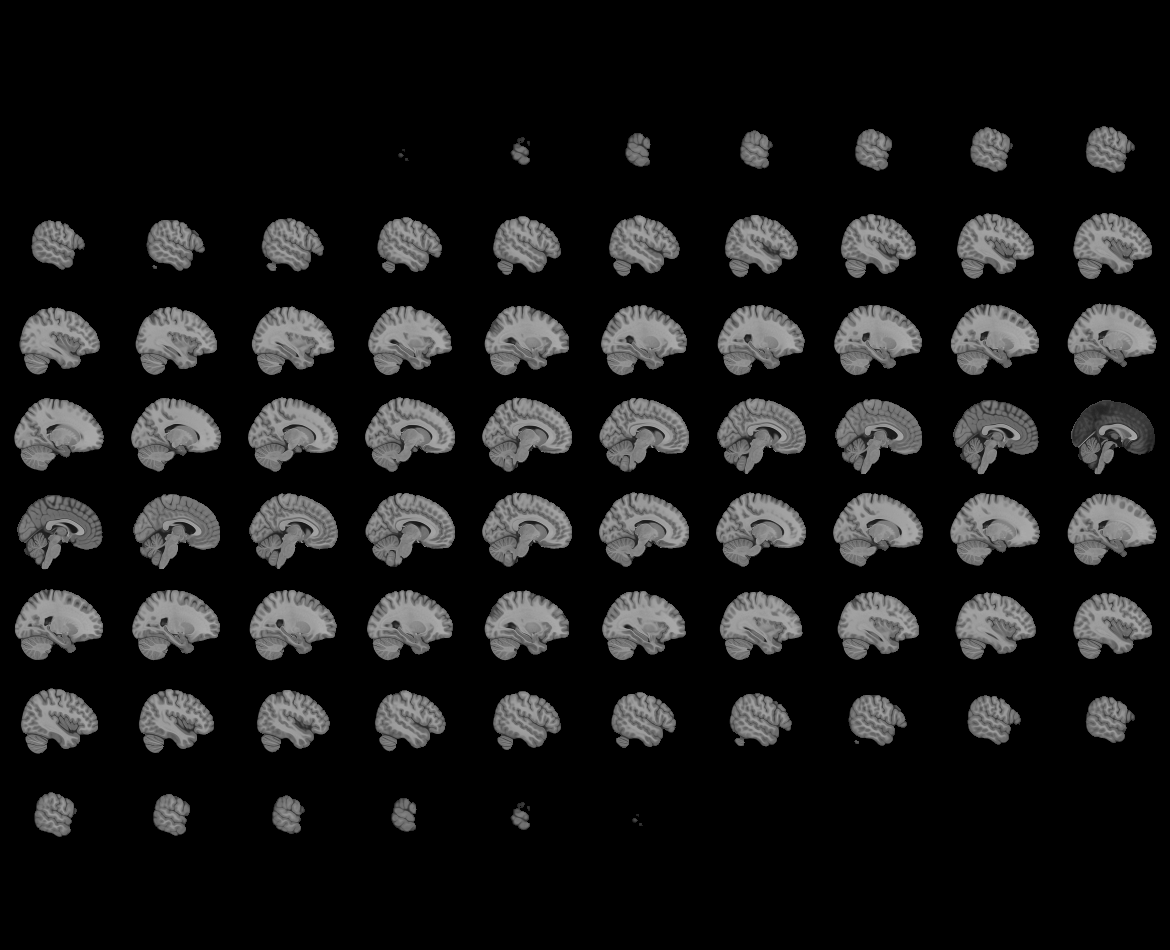
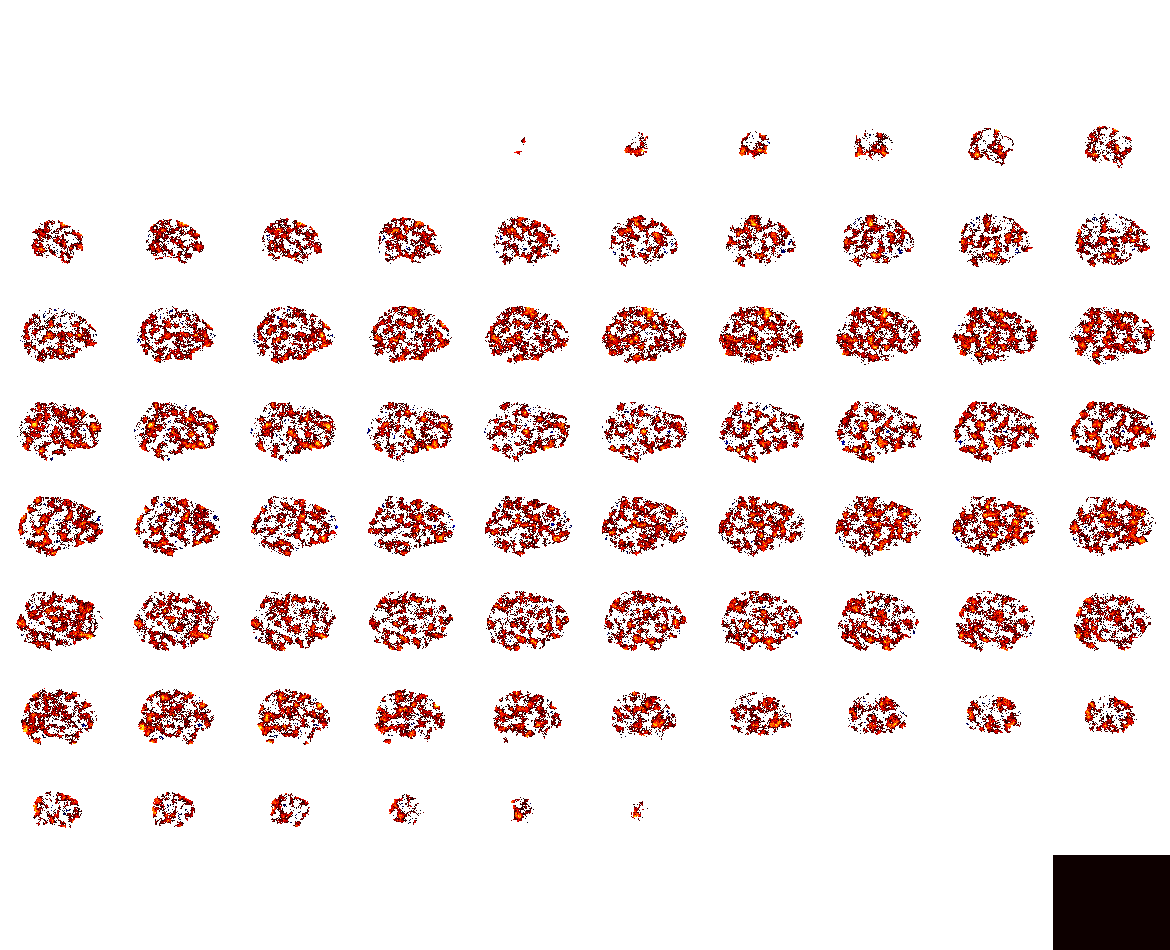

In [14]:
# Jupyter cell: visualize sparse‐DL discriminant map with Z‐threshold and interactive view

import os
import numpy as np
from nilearn.maskers import NiftiMasker
from nilearn.plotting import view_img

# --- assume you’ve already run ---
# U, Vt = spatial_dl(train_maps, train_labels)
# and defined fold_dir

# 1) Load & fit the mask, standardizing to Z‐scores
mask_path = os.path.join(fold_dir, 'group_gm_mask_fold.nii.gz')
masker = NiftiMasker(
    mask_img=mask_path,
    standardize=True,     # convert your weight map into Z‐scores
    dtype='float32'
)
masker.fit()

# 2) Extract your voxel weights (shape: (V,))
w_voxel = Vt.ravel()

# 3) Inverse‐transform back into 3D NIfTI
stat_img = masker.inverse_transform(w_voxel[np.newaxis, :])
out_fname = os.path.join(fold_dir, 'dl_discriminant_map_z.nii.gz')
stat_img.to_filename(out_fname)

# 4) Create an interactive HTML viewer, thresholding at Z = 2.3
#    display_mode='ortho' gives three orthogonal cuts; you can change to 'x', 'y', 'z' or 'lzr'
viewer = view_img(
    stat_img,
    threshold=0,
    # display_mode='ortho',
    # cut_coords=(0, -20, 30),   # or 'auto'
    cmap='cold_hot',
    title='Sparse-DL Discriminant (Z ≥ 2.3)'
)

# In a Jupyter notebook this will render inline as an interactive view:
viewer

In [ ]:
from sklearn.covariance import OAS,LedoitWolf, EmpiricalCovariance
from scipy.linalg import eigh,subspace_angles
from pyriemann.utils.tangentspace import untangent_space, mean_covariance

# https://ieeexplore.ieee.org/abstract/document/1467563
def spatial_fda(train_maps,train_labels,within=True,metric="riemann"):

    # Separate Train Maps into Groups
    groupA_train = train_maps[train_labels==1]
    groupB_train = train_maps[train_labels==0]
    print(groupA_train.shape, groupB_train.shape)
    # Calculate Average Set of Train Spatial Maps per Group
    groupA_mean_train = np.mean(groupA_train,axis=0)
    groupB_mean_train = np.mean(groupB_train,axis=0)
    # cov_est = EmpiricalCovariance(assume_centered=True)
    # cov_est = LedoitWolf(assume_centered=True)
    cov_est = OAS(assume_centered=True)

    all_mean = np.mean(train_maps,axis=0)
    Sb = groupA_train.shape[0]*cov_est.fit((groupA_mean_train - all_mean).T).covariance_
    Sb += groupB_train.shape[0]*cov_est.fit((groupB_mean_train - all_mean).T).covariance_
    # print(Sb.shape)

    # Sb = cov_est.fit((groupA_mean_train - groupB_mean_train).T).covariance_
    # groupA_within = mean_covariance(np.array([cov_est.fit((A-groupA_mean_train).T).covariance_ for A in groupA_train]),metric=metric)
    # groupB_within = mean_covariance(np.array([cov_est.fit((B-groupB_mean_train).T).covariance_ for B in groupB_train]),metric=metric)
    # Sw = mean_covariance(np.stack([groupA_within, groupB_within], axis=0), metric=metric)
    
    # Sb = (groupA_mean_train - groupB_mean_train)@(groupA_mean_train - groupB_mean_train).T

    if within:
        groupA_within = np.sum(np.array([cov_est.fit((A-groupA_mean_train).T).covariance_ for A in groupA_train]),axis=0)
        groupB_within = np.sum(np.array([cov_est.fit((B-groupB_mean_train).T).covariance_ for B in groupB_train]),axis=0)
        Sw = (groupA_within + groupB_within) 
        print(Sw.shape)

        # # An Alternative Using Weighted & Riemannian Means Instead of Sums
        # Sb /= groupA_train.shape[0] + groupB_train.shape[0]
        # groupA_within = np.array([cov_est.fit((A-groupA_mean_train).T).covariance_ for A in groupA_train])
        # groupB_within = np.array([cov_est.fit((B-groupB_mean_train).T).covariance_ for B in groupB_train])
        # Sw = mean_covariance(np.vstack((groupA_within,groupB_within)),metric=metric)
        # For class A (shape: (N_A, C, V)) with mean groupA_mean_train (C, V)

        # # An Alternative Using Pooling Prior to Covariance Formation
        # deviations_A = np.concatenate([subject - groupA_mean_train for subject in groupA_train], axis=1)
        # deviations_A = deviations_A.T  # shape: (N_A * V, C)
        # # For class B (shape: (N_B, C, V)) with mean groupB_mean_train (C, V)
        # deviations_B = np.concatenate([subject - groupB_mean_train for subject in groupB_train], axis=1)
        # deviations_B = deviations_B.T  # shape: (N_B * V, C)
        # # Pool all deviations together:
        # all_deviations = np.vstack((deviations_A, deviations_B))
        # # Compute the pooled covariance:
        # Sw = cov_est.fit(all_deviations).covariance_
        # print("Pooled within-class covariance (both classes) shape:", Sw.shape)
        eigvals = np.linalg.eigvalsh(Sw)
        min_eig = eigvals[0]

        if min_eig < 1e-6:
            # Sw is not PSD.  Option A: replace with identity
            print(f"Warning: Sw has min eigenvalue {min_eig:.2e} < 0; replacing with I")
            Sw = np.eye(Sw.shape[0])
            
        _, U = eigh(Sb,Sw)
    else:
        _, U = eigh(Sb)
    
    return U, U.T

fold = 0
fold_dir    = os.path.join(outputfolder, f"fold_{fold}")
indices_dir = os.path.join(fold_dir, "Indices")
if not os.path.exists(indices_dir):
    os.makedirs(indices_dir)

# out_fname = os.path.join(fold_dir, 'stage2_subj_x_comp_x_vox.npy')
# all_data = np.load(out_fname)

# load train/test indices
train_idx = np.load(os.path.join(indices_dir, "train_idx.npy"))
test_idx  = np.load(os.path.join(indices_dir, "test_idx.npy"))

labels = np.load(os.path.join(outputfolder,"labels.npy"))

# all_data = all_data.transpose(0, 2, 1)
# print(all_data.shape)

train_maps = all_data[train_idx]
train_labels = labels[train_idx]

U, Vt = spatial_fda(train_maps, train_labels,within=True,metric=settings["metric"])
discrim_map_name = os.path.join(fold_dir, 'discrim_map.npy')
np.save(discrim_map_name, U)

In [ ]:
from joblib import Parallel, delayed
import numpy as np
from sklearn.covariance import OAS,LedoitWolf, EmpiricalCovariance
from scipy.linalg import eigh,subspace_angles

fold = 0
fold_dir    = os.path.join(outputfolder, f"fold_{fold}")
indices_dir = os.path.join(fold_dir, "Indices")
if not os.path.exists(indices_dir):
    os.makedirs(indices_dir)

# load train/test indices
train_idx = np.load(os.path.join(indices_dir, "train_idx.npy"))
test_idx  = np.load(os.path.join(indices_dir, "test_idx.npy"))
labels = np.load(os.path.join(outputfolder,"labels.npy"))

out_fname = os.path.join(fold_dir, 'stage2_subj_x_comp_x_vox.npy')
all_data = np.load(out_fname)
all_data = all_data.transpose(0, 2, 1)
print(all_data.shape)

discrim_map_name = os.path.join(fold_dir, 'discrim_map.npy')
U = np.load(discrim_map_name)

In [22]:
U.shape
np.linalg.norm(U_subset)

5.748328642079092

In [23]:
U_subset = U[:,0]
U_subset /=np.linalg.norm(U_subset)
print(np.linalg.norm(U_subset))
projected_data = np.array([U_subset.T@sub_data for sub_data in all_data])

1.0


In [ ]:
rotated_map_name = os.path.join(fold_dir, 'rotated_maps.npy')
np.save(rotated_map_name, projected_data)

In [19]:
projected_data.shape

(332, 263281)

In [ ]:
from joblib import Parallel, delayed
import numpy as np
from sklearn.covariance import OAS,LedoitWolf, EmpiricalCovariance
from scipy.linalg import eigh,subspace_angles

fold = 0
fold_dir    = os.path.join(outputfolder, f"fold_{fold}")
indices_dir = os.path.join(fold_dir, "Indices")
if not os.path.exists(indices_dir):
    os.makedirs(indices_dir)

# load train/test indices
train_idx = np.load(os.path.join(indices_dir, "train_idx.npy"))
test_idx  = np.load(os.path.join(indices_dir, "test_idx.npy"))
labels = np.load(os.path.join(outputfolder,"labels.npy"))

rotated_map_name = os.path.join(fold_dir, 'rotated_maps.npy')
projected_data = np.load(rotated_map_name)

(332, 263281)
265
After centering+SVD: X_train shape = (265, 265)
Using 10-fold StratifiedKFold
Using 10-fold StratifiedKFold

--- Tuning LinearSVC ---
→ Best LinearSVC params: {'C': 1.0004151219699197e-07}

LinearSVC classification report:
              precision    recall  f1-score   support

           0      0.600     0.538     0.568        39
           1      0.438     0.500     0.467        28

    accuracy                          0.522        67
   macro avg      0.519     0.519     0.517        67
weighted avg      0.532     0.522     0.525        67



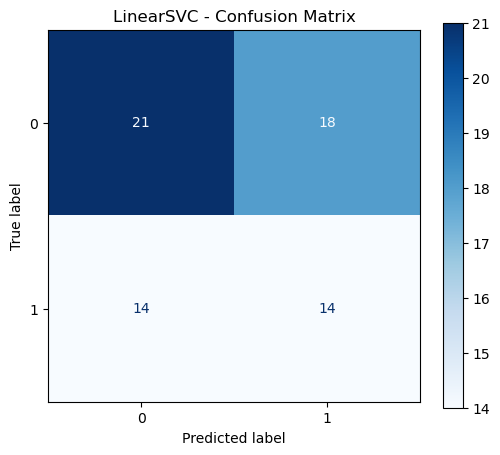

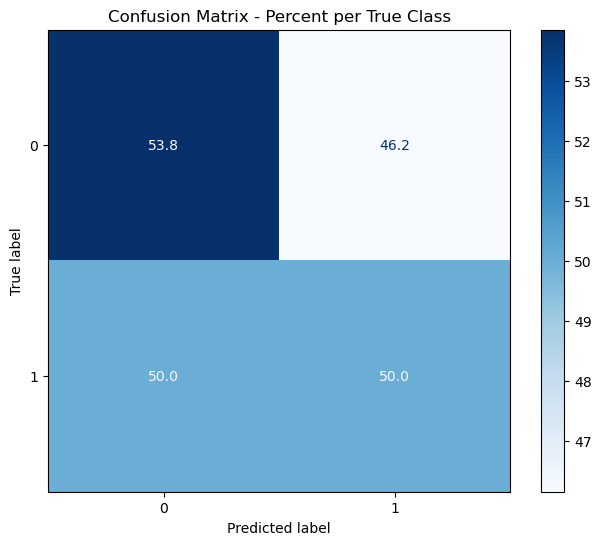


--- Tuning LogisticL1 ---
→ Best LogisticL1 params: {'C': 0.0003243817363193787}

LogisticL1 classification report:
              precision    recall  f1-score   support

           0      0.543     0.487     0.514        39
           1      0.375     0.429     0.400        28

    accuracy                          0.463        67
   macro avg      0.459     0.458     0.457        67
weighted avg      0.473     0.463     0.466        67



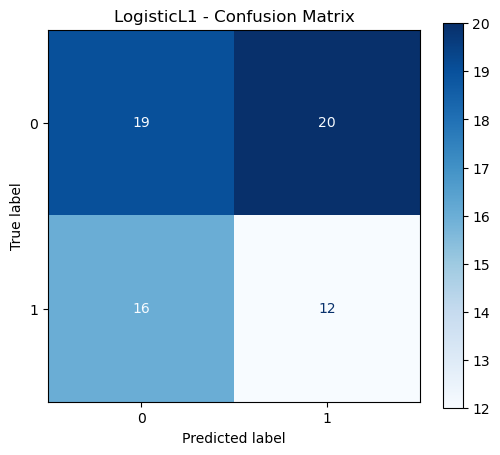

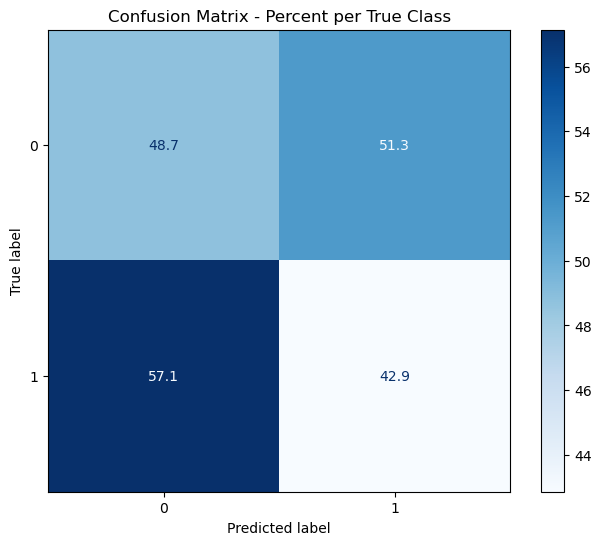


--- Tuning LogisticL2 ---


/home/mrstats/zaisou/.conda/envs/IFAslurmv2/lib/python3.11/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0052024083667899e-07] before, using random point [2.207800311265364e-06]
  warnings.warn(


→ Best LogisticL2 params: {'C': 1e-07}

LogisticL2 classification report:
              precision    recall  f1-score   support

           0      0.581     0.641     0.610        39
           1      0.417     0.357     0.385        28

    accuracy                          0.522        67
   macro avg      0.499     0.499     0.497        67
weighted avg      0.513     0.522     0.516        67



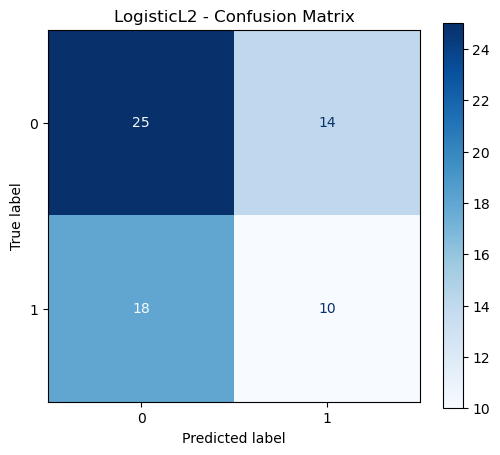

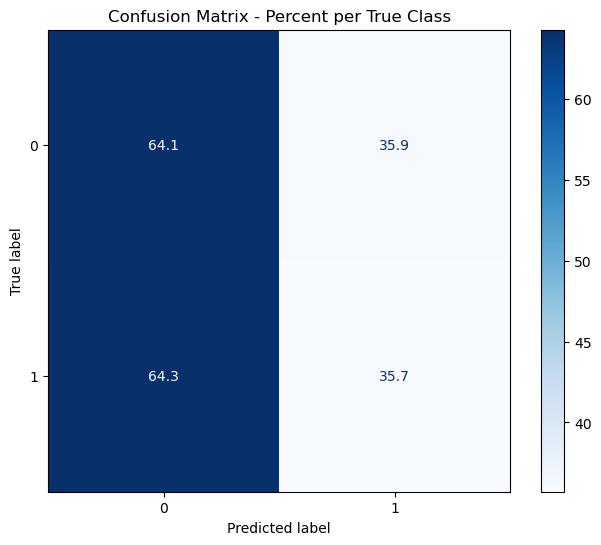

In [25]:
import os
import sys
import pandas as pd
from itertools import product

import numpy as np
from scipy import stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns


from skopt import gp_minimize
from skopt.space import Real, Integer

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, ElasticNet, Ridge
from sklearn.svm import SVR
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, r2_score, make_scorer, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import DictionaryLearning, PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import  LeaveOneOut
from sklearn.base import BaseEstimator, ClassifierMixin

from pyriemann.utils.tangentspace import  unupper
from pyriemann.estimation import Covariances
from scipy.linalg import eigh


from collections import Counter

import sys
sys.path.append('/project/3022057.01/IFA/utils')

import regression
import tangent
from importlib import reload

# after editing regression.py:
reload(regression)
reload(tangent)

# now pull in your updated functions
from regression import deconfound
from tangent    import tangent_transform


def classification_pipeline(
    X_train, y_train, X_test, y_test, deconf=True,
    con_train=None, con_test=None, cat_train=None, cat_test=None,
    display_labels=None
):
    # class_counts = Counter(y_train)
    # min_count    = min(class_counts.values())
    # if min_count < 10:
    #     cv = LeaveOneOut()
    #     print(f"Not enough samples per class (min={min_count}), using LOO-CV")
    # else:
        # cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
        # print("Using 10-fold StratifiedKFold")
    
    if deconf:
        X_train, X_test = deconfound(
            X_train, con_train, cat_train,
            X_test=X_test,
            con_confounder_test=con_test,
            cat_confounder_test=cat_test,
            output_path=os.path.join(fold_dir, "betas_fold0")
        )
        X_train = np.asarray(X_train, dtype=float)
        X_test  = np.asarray(X_test,  dtype=float)

    # 2) Build a DR pipeline: center → truncated SVD
    n_components = np.min(X_train.shape)
    print(n_components)
    dr_pipeline = make_pipeline(
        StandardScaler(with_mean=True,  with_std=False),  # subtract train-mean only
        TruncatedSVD(n_components=n_components,
                     algorithm='randomized',
                     random_state=0)
    )

    # fit on train, transform both
    X_train = dr_pipeline.fit_transform(X_train)
    X_test  = dr_pipeline.transform(X_test)
    print(f"After centering+SVD: X_train shape = {X_train.shape}")

    class_counts = Counter(y_train)
    min_count    = min(class_counts.values())
    if min_count < 10:
        cv = LeaveOneOut()
        print(f"Not enough samples per class (min={min_count}), using LOO-CV")
    else:
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
        print("Using 10-fold StratifiedKFold")
    # cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    print("Using 10-fold StratifiedKFold")
    # 2) model specs: (constructor, fixed‐kwargs, search‐space, param‐names)
    models = {
        'LinearSVC': (
            LinearSVC,
            {'penalty':'l2','loss':'squared_hinge','class_weight':'balanced',
             'max_iter':10000,'random_state':0},
            [Real(1e-7,1e2,prior='log-uniform',name='C')],
            ['C']
        ),
        'LogisticL1': (
            LogisticRegression,
            {'penalty':'l1','solver':'liblinear','class_weight':'balanced',
             'max_iter':10000,'random_state':0},
            [Real(1e-7,1e2,prior='log-uniform',name='C')],
            ['C']
        ),
        'LogisticL2': (
            LogisticRegression,
            {'penalty':'l2','solver':'lbfgs','class_weight':'balanced',
             'max_iter':10000,'random_state':0},
            [Real(1e-7,1e2,prior='log-uniform',name='C')],
            ['C']
        ),
    }

    # 3) loop over them
    final_clfs = {}
    results = {}
    for name, (Cls, base_kwargs, space, param_names) in models.items():
        print(f"\n--- Tuning {name} ---")

        def _obj(params):
            # map list -> dict
            p = dict(zip(param_names, params))
            # build clf
            clf_kwargs = base_kwargs.copy()
            clf_kwargs.update(p)
            clf = Cls(**clf_kwargs)
            # maximize f1_macro
            vals = cross_val_score(clf, X_train, y_train,
                                   cv=cv, scoring='f1_macro', n_jobs=-1)
            vals = vals.mean()
            # vals = np.clip(vals, 1e-6, 1-1e-6)
            # geometric mean via gmean (handles shape etc.)
            # geom = gmean(vals)
            return -vals

        # run GP search
        res = gp_minimize(
            _obj,
            space,
            n_calls=20,
            n_initial_points=5,
            random_state=0,
            acq_optimizer='lbfgs',
            n_jobs=1
        )
        best_params = dict(zip(param_names, res.x))
        print(f"→ Best {name} params:", best_params)

        # fit final
        clf = Cls(**{**base_kwargs, **best_params})
        clf.fit(X_train, y_train)
        final_clfs[name] = clf

        # evaluate on test
        y_pred = clf.predict(X_test)
        print(f"\n{name} classification report:")
        print(classification_report(y_test, y_pred, digits=3, zero_division=0))

        # plot confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=display_labels)
        fig, ax = plt.subplots(figsize=(6,5))
        disp.plot(ax=ax, cmap='Blues', values_format='d')
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        fig, ax = plt.subplots(figsize=(8, 6))
        disp_norm = ConfusionMatrixDisplay(
            confusion_matrix=cm_normalized,
            display_labels=display_labels
        )
        disp_norm.plot(cmap='Blues', values_format=".1f", ax=ax)
        plt.title("Confusion Matrix - Percent per True Class")
        plt.show()
        
        results[name] = {
            'clf': clf,
            'cm': cm,
            'cm_norm': cm_normalized
        }
    return results


# map = -1
# projected_data_map = projected_data[:,map,:]
# map = -1
projected_data_map = projected_data
print(projected_data_map.shape)
X_train = projected_data_map[train_idx]
X_test = projected_data_map[test_idx]
y_train = labels[train_idx]
y_test =  labels[test_idx]
con_train = con_confounders.iloc[train_idx]
con_test = con_confounders.iloc[test_idx]
cat_train = cat_confounders.iloc[train_idx]
cat_test = cat_confounders.iloc[test_idx]

# from imblearn.under_sampling import RandomUnderSampler

# # 1) After you’ve already done your train/test split:
# #    X_train, y_train, con_train, cat_train are in sync

# # 2) Create the sampler
# rus = RandomUnderSampler(random_state=0)
# print("Original class distribution:", Counter(y_train))

# # 3) Fit & resample, capturing the indices it keeps
# X_train, y_train = rus.fit_resample(X_train, y_train)
# idx_kept = rus.sample_indices_    # these are the row-indices of X_train that were retained

# # 4) Apply those same indices to your confounder tables
# con_train = con_train.iloc[idx_kept].reset_index(drop=True)
# cat_train = cat_train.iloc[idx_kept].reset_index(drop=True)

# print("Balanced   class distribution:", Counter(y_train))


res = classification_pipeline(
    X_train, y_train, X_test, y_test, deconf=settings["deconfound"],
    con_train=con_train, con_test=con_test, cat_train=cat_train, cat_test=cat_test,
    display_labels=None
)

In [ ]:
u,e,v = np.linalg.svd(projected_data_map,full_matrices=False)

In [ ]:
v.shape

In [ ]:
import os
import numpy as np
from joblib import Parallel, delayed
import pickle

# --- pick your fold ---
fold = 0
fold_dir = os.path.join(outputfolder, f"fold_{fold}")
dr_dir   = os.path.join(fold_dir, "dualreg")

# --- find all stage-1 time-series txt files ---
ts_files = sorted(
    fn for fn in os.listdir(dr_dir)
    if fn.startswith("dr_stage1_subject")
       and fn.endswith(".txt")
)
n_subj = len(ts_files)
print(f"Found {n_subj} stage-1 time-series files")

# --- loader for a single file ---
def load_ts(fname):
    """
    Returns array of shape (n_timepoints, n_components)
    """
    return np.loadtxt(os.path.join(dr_dir, fname), dtype="float32")

# --- parallel load across 20 cores ---
list_ts = Parallel(n_jobs=20, verbose=5)(
    delayed(load_ts)(f) for f in ts_files
)

# --- check shapes of first few subjects ---
for i, arr in enumerate(list_ts[:3]):
    print(f"Subj {i:02d}: timepoints={arr.shape[0]}, components={arr.shape[1]}")

# --- save as a pickle (list of arrays) ---
out_pkl = os.path.join(fold_dir, "stage1_ts_list.pkl")
with open(out_pkl, "wb") as f:
    pickle.dump(list_ts, f)

print("Saved time-series list to", out_pkl)